In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# CÀI ĐẶT CÂY QUYẾT ĐỊNH 

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature       
        self.threshold = threshold   
        self.left = left             
        self.right = right           
        self.value = value           

    def is_leaf_node(self):
        return self.value is not None

class DecisionTreeRegressor:
    def __init__(self, max_depth=10, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def fit(self, X, y):
        # 1. HÀM FIT: Nhận dữ liệu và bắt đầu mọc cây
        X_array = X.values if isinstance(X, pd.DataFrame) else X
        y_array = y.values if isinstance(y, pd.Series) else y
        self.root = self._grow_tree(X_array, y_array)

    def _grow_tree(self, X, y, depth=0):
            n_samples, n_feats = X.shape

            # Điều kiện biên để dừng phân tách cây
            if (depth >= self.max_depth or 
                n_samples < self.min_samples_split or 
                np.var(y) == 0.0):
                leaf_value = np.mean(y) # Giá trị lá là trung bình của y
                return Node(value=leaf_value)

           # 
            feat_idxs = np.arange(n_feats) 

            # Tìm kiếm điểm chia tốt nhất (Best Split) trên toàn bộ không gian đặc trưng
            best_feat, best_thresh = self._best_split(X, y, feat_idxs)

            # Tạo nhánh con đệ quy
            left_idxs = np.argwhere(X[:, best_feat] <= best_thresh).flatten()
            right_idxs = np.argwhere(X[:, best_feat] > best_thresh).flatten()
            
            if len(left_idxs) == 0 or len(right_idxs) == 0:
                return Node(value=np.mean(y))

            left = self._grow_tree(X[left_idxs, :], y[left_idxs], depth + 1)
            right = self._grow_tree(X[right_idxs, :], y[right_idxs], depth + 1)
            return Node(feature=best_feat, threshold=best_thresh, left=left, right=right)

    def _best_split(self, X, y, feat_idxs):
        # 3. HÀM BEST_SPLIT: Tìm điểm cắt giảm phương sai nhiều nhất
        best_gain = -1
        split_idx, split_thresh = 0, 0
        current_variance = np.var(y) * len(y) # Tổng phương sai của node hiện tại

        for feat_idx in feat_idxs: # Duyệt qua từng đặc trưng
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)
            
            
            # Lấy toàn bộ giá trị unique
            thresholds = np.unique(X_column)

            for thresh in thresholds: # duyệt qua từng điểm chia 
                left_idxs = np.argwhere(X_column <= thresh).flatten() # Tìm chỉ số của các mẫu thuộc nhánh trái
                right_idxs = np.argwhere(X_column > thresh).flatten()

                # bỏ qua split lỗi nếu một trong hai nhánh không có mẫu nào
                if len(left_idxs) == 0 or len(right_idxs) == 0:
                    continue

                # Tính phương sai của nhánh trái và phải
                var_l = np.var(y[left_idxs])
                var_r = np.var(y[right_idxs]) # Tính phương sai của nhánh trái và phải
                n_l, n_r = len(left_idxs), len(right_idxs) # Số lượng mẫu trong nhánh trái và phải

                variance_reduction = current_variance - ((n_l * var_l) + (n_r * var_r)) # công thức giảm phương sai

                # Cập nhật split tốt nhất nếu tìm thấy
                if variance_reduction > best_gain:
                    best_gain = variance_reduction
                    split_idx = feat_idx
                    split_thresh = thresh

        return split_idx, split_thresh

    def predict(self, X):
        # 4. HÀM PREDICT: Dự đoán hàng loạt
        X_array = X.values if isinstance(X, pd.DataFrame) else X
        return np.array([self._traverse_tree(x, self.root) for x in X_array])

    def _traverse_tree(self, x, node):
        # 5. HÀM TRAVERSE_TREE: Duyệt từng dòng dữ liệu từ gốc đến lá
        if node.is_leaf_node():
            return node.value
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

In [5]:
df_train = pd.read_csv('retail_train_80.csv')
target_col = 'sales_amount_log'

X_train = df_train.drop(columns=[target_col])
y_train = df_train[target_col]

df_test = pd.read_csv('retail_test_20.csv')
X_test = df_test.drop(columns=[target_col])
y_test = df_test[target_col]

print(f"Kích thước Train: {X_train.shape} | Kích thước Test: {X_test.shape}")
# CELL 4: HUẤN LUYỆN & TÍNH TOÁN ĐÁNH GIÁ

print("Đang huấn luyện mô hình ")
model = DecisionTreeRegressor(max_depth=10, min_samples_split=2)
model.fit(X_train, y_train)
print("Huấn luyện thành công!")

# Dự đoán
y_pred = model.predict(X_test)

# Đánh giá bằng công thức toán học (Numpy)
mae = np.mean(np.abs(y_test - y_pred))
mse = np.mean((y_test - y_pred) ** 2)
rmse = np.sqrt(mse)

print("\n--- KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ---")
print(f"1. MAE (Mean Absolute Error)     : {mae:.4f}")
print(f"2. MSE (Mean Squared Error)      : {mse:.4f}")
print(f"3. RMSE (Root Mean Squared Error): {rmse:.4f}")

Kích thước Train: (96000, 79) | Kích thước Test: (24000, 79)
Đang huấn luyện mô hình 
Huấn luyện thành công!

--- KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ---
1. MAE (Mean Absolute Error)     : 0.4317
2. MSE (Mean Squared Error)      : 0.2434
3. RMSE (Root Mean Squared Error): 0.4933


In [7]:

# ==============================
# THỬ NGHIỆM max_depth = 20
# ==============================

model_depth20 = DecisionTreeRegressor(
    max_depth=20,
    min_samples_split=2
)

# Train model
model_depth20.fit(X_train, y_train)

# Predict
y_pred_20 = model_depth20.predict(X_test)

# Đưa dữ liệu về giá trị thật nếu đã log

# Evaluation
mae = np.mean(np.abs(y_test - y_pred))
mse = np.mean((y_test - y_pred) ** 2)
rmse = np.sqrt(mse)

print("===== MAX DEPTH = 20 =====")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)






===== MAX DEPTH = 20 =====
MAE : 0.4316851487733697
MSE : 0.24337403366127805
RMSE: 0.49332953860607015


In [8]:
# ==============================
# THỬ NGHIỆM max_depth = 30
# ==============================

model_depth30 = DecisionTreeRegressor(
    max_depth=30,
    min_samples_split=2
)

# Train model
model_depth30.fit(X_train, y_train)

# Predict
y_pred_30 = model_depth30.predict(X_test)

# Đưa dữ liệu về giá trị thật nếu đã log


# Evaluation
mae_30 = np.mean(np.abs(y_test - y_pred_30))
mse_30 = np.mean((y_test - y_pred_30) ** 2)
rmse_30 = np.sqrt(mse_30)

print("===== MAX DEPTH = 30 =====")
print("MAE :", mae_30)
print("MSE :", mse_30)
print("RMSE:", rmse_30)


===== MAX DEPTH = 30 =====
MAE : 0.5087659791204254
MSE : 0.4953231062709274
RMSE: 0.7037919481430058


Kích thước Train: (96000, 79) | Kích thước Test: (24000, 79)


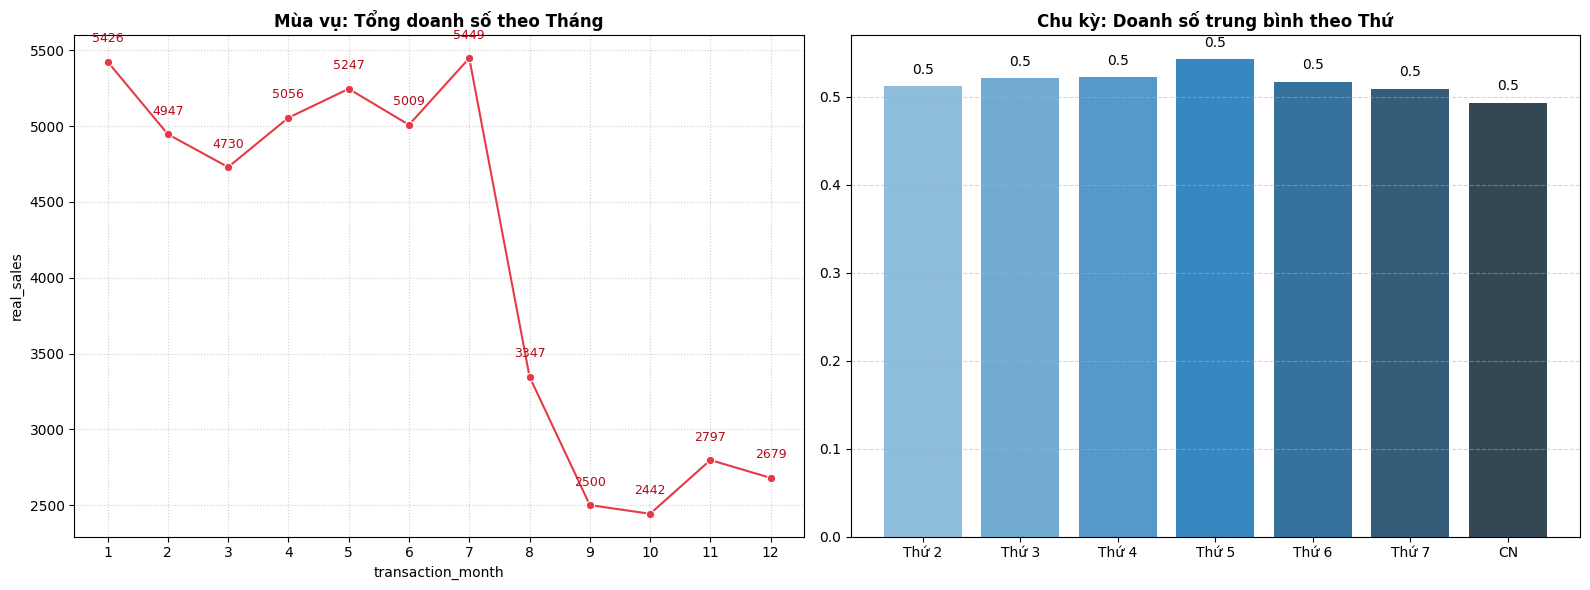

In [10]:

# TẢI DỮ LIỆU & PHÂN TÍCH THỜI GIAN

df_train = pd.read_csv('retail_train_80.csv')
target_col = 'sales_amount_log'

X_train = df_train.drop(columns=[target_col])
y_train = df_train[target_col]

df_test = pd.read_csv('retail_test_20.csv')
X_test = df_test.drop(columns=[target_col])
y_test = df_test[target_col]

print(f"Kích thước Train: {X_train.shape} | Kích thước Test: {X_test.shape}")

# Phân tích chuỗi thời gian (Quy đổi log về doanh số thực tế)
df_train['real_sales'] = np.expm1(df_train['sales_amount_log'])
monthly_sales = df_train.groupby('transaction_month')['real_sales'].sum().reset_index()
weekday_sales = df_train.groupby('transaction_dayofweek')['real_sales'].mean().reset_index()

# Vẽ 2 biểu đồ phân tích 
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# Đồ thị 1: Mùa vụ (Tháng)
sns.lineplot(data=monthly_sales, x='transaction_month', y='real_sales', marker='o', color='#e63946', ax=axes[0])
for i, row in monthly_sales.iterrows():
    axes[0].text(row['transaction_month'], row['real_sales'] + (monthly_sales['real_sales'].max() * 0.02),
                 f"{row['real_sales']:.0f}", ha='center', va='bottom', fontsize=9, color='#b70918')
axes[0].set_title('Mùa vụ: Tổng doanh số theo Tháng', fontweight='bold')
axes[0].set_xticks(range(1, 13))
axes[0].grid(True, linestyle=':', alpha=0.6)

# Đồ thị 2: Chu kỳ tuần (Thứ)
bars = axes[1].bar(weekday_sales['transaction_dayofweek'], weekday_sales['real_sales'], color=sns.color_palette('Blues_d', 7))
for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., h + (weekday_sales['real_sales'].max() * 0.02),
                 f"{h:.1f}", ha='center', va='bottom', fontsize=10)
axes[1].set_title('Chu kỳ: Doanh số trung bình theo Thứ', fontweight='bold')
axes[1].set_xticks(range(0, 7))
axes[1].set_xticklabels(['Thứ 2', 'Thứ 3', 'Thứ 4', 'Thứ 5', 'Thứ 6', 'Thứ 7', 'CN'])
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()